# Weight Cap 실험 — x_max ∈ {0.3, 0.6}

자산별 비중 상한을 걸었을 때 성과가 어떻게 달라지는지 본다.

- 학습·병합은 `run_xmax_sweep.py` 가 전담 (x_max=0.3 완주 → 0.6 순차)
- 체크포인트는 `_xm0.3` / `_xm0.6` 태그로 기존(x_max=1.0) 결과와 분리
- 분석 로직은 기존 `.py` 모듈 재사용 — 이 노트북에는 호출만 둔다

| 파일명 예시 | 의미 |
| --- | --- |
| `dfl_mdd_30_inds_h126_d20_l0.5_CLARABEL.pkl` | x_max = 1.0 (기존) |
| `dfl_mdd_30_inds_h126_xm0.3_d20_l0.5_CLARABEL.pkl` | x_max = 0.3 |

## 1. 설정

In [64]:
import os, sys, pickle, subprocess, time, importlib, re
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

import benchmarks, performance, carryforward
for _m in (benchmarks, performance, carryforward):
    importlib.reload(_m)

from benchmarks import (build_bench_store, attach_date_idx,
                        compute_turnover, rebalance_dates)
from carryforward import apply_carryforward, parse_lb, parse_n1
from performance import compute_performance, apply_tc, build_equity_curve

# ── 실험 설정 ──
N_STOCKS      = 10
HORIZON       = 126
REBAL         = 21
SOLVER        = "CLARABEL"
DELTA         = 20
LAM_LIST      = [0.3, 0.5, 0.7, 1.0]
LOOKBACK_LIST = [252, 504]
N1_LIST       = [0.1, 0.2, 0.3, 0.4]
XMAX_LIST     = [0.2, 0.3, 0.6]           # 이번 실험
XMAX_ALL      = XMAX_LIST + [1.0]    # 비교 대상 (1.0 = 기존 결과)

VAL_YEARS, TEST_YEARS, N_FOLDS = 5, 1, 8
CKPT_DIR   = "./checkpoint"
PLOT_DIR   = "./plots/xmax"
RESULT_DIR = "./results"
for _d in (CKPT_DIR, PLOT_DIR, RESULT_DIR):
    os.makedirs(_d, exist_ok=True)

configs = [{"LOOKBACK": lb, "n1": n1} for lb in LOOKBACK_LIST for n1 in N1_LIST]
print(f"{N_STOCKS} inds, H={HORIZON}, x_max {XMAX_ALL}, config {len(configs)}개")

10 inds, H=126, x_max [0.2, 0.3, 0.6, 1.0], config 8개


## 2. 데이터 · fold

In [62]:
inds = pd.read_csv(f"csv/{N_STOCKS}_industry.csv")
inds["Date"] = pd.to_datetime(inds["Date"])
inds = inds.set_index("Date").sort_index()
inds = inds[~inds.index.duplicated(keep="first")] / 100.0

stock_names = inds.columns.tolist()
full_np     = inds.values
full_dates  = inds.index
d, C_cap    = 1.0, 1.0

def date_to_idx(s):
    return full_dates.searchsorted(pd.Timestamp(s), side="left")

def make_folds(horizon):
    fs = []
    for f in range(N_FOLDS):
        ty = 2018 + f
        fs.append({
            "fold"          : f + 1,
            "train_end_idx" : date_to_idx(f"{ty - VAL_YEARS}-01-01"),
            "val_start_idx" : date_to_idx(f"{ty - VAL_YEARS}-01-01"),
            "val_end_idx"   : date_to_idx(f"{ty}-01-01"),
            "test_start_idx": date_to_idx(f"{ty}-01-01"),
            "test_end_idx"  : min(date_to_idx(f"{ty + TEST_YEARS}-01-01") + horizon,
                                  len(full_np)),
            "val_year"      : f"{ty - VAL_YEARS}~{ty - 1}",
            "test_year"     : ty,
        })
    return fs

folds = make_folds(HORIZON)
N_WIN = sum(len(rebalance_dates(f, 252, HORIZON, REBAL)) for f in folds)
print(f"{len(full_np)}일, {full_dates[0]:%Y-%m-%d} ~ {full_dates[-1]:%Y-%m-%d}")
print(f"fold {len(folds)}개, config당 리밸런싱 윈도우 {N_WIN}개")

6539일, 2000-01-03 ~ 2025-12-31
fold 8개, config당 리밸런싱 윈도우 94개


## 3. 학습 실행

`run_xmax_sweep.py` 가 **x_max=0.3 전체(DFL-MDD 16 shard → 병합 → DFL-MVO 4 shard)를
끝낸 뒤 0.6 을 시작**한다. 0.6 이 도는 동안 0.3 결과로 아래 분석을 진행할 수 있다.

예상 소요: x_max 하나당 DFL-MDD ~8시간 + DFL-MVO ~3시간 → 전체 ~22시간

In [65]:
PY  = sys.executable
ENV = {**os.environ, "PYTHONIOENCODING": "utf-8", "PYTHONUTF8": "1"}
os.makedirs("./logs", exist_ok=True)

import psutil
free = psutil.virtual_memory().available / 1e9
JOBS = max(1, min(16, int((free - 3.0) / 1.05)))   # 워커당 ~1.4GB
print(f"가용 RAM {free:.1f} GB → DFL-MDD 동시 {JOBS}개")

sweep_log = f"./logs/xmax_sweep_{N_STOCKS}_h{HORIZON}.txt"
f_sweep = open(sweep_log, "w", encoding="utf-8")
proc_sweep = subprocess.Popen(
    [PY, "-u", "run_xmax_sweep.py",
     "--data", str(N_STOCKS), "--horizon", str(HORIZON),
     "--delta", str(DELTA), "--solver", SOLVER,
     "--xmax", *[f"{x:g}" for x in XMAX_LIST],
     "--jobs", str(JOBS), "--python", PY],
    stdout=f_sweep, stderr=subprocess.STDOUT, env=ENV)

print(f"sweep 시작 — x_max {XMAX_LIST} 순차 (PID {proc_sweep.pid})")
print(f"  진행 로그: {sweep_log}")

가용 RAM 17.3 GB → DFL-MDD 동시 13개
sweep 시작 — x_max [0.2, 0.3, 0.6] 순차 (PID 10772)
  진행 로그: ./logs/xmax_sweep_10_h126.txt


### 3-1. 진행 확인 (반복 실행)

In [71]:
rc = proc_sweep.poll()
print("실행 중" if rc is None else f"sweep 종료 (rc={rc})")
print(open(sweep_log, encoding="utf-8").read()[-1000:])

PER     = len(LOOKBACK_LIST) * len(folds)          # shard(lam,n1) 당 유닛 = 16
GRAND   = len(LAM_LIST) * len(N1_LIST) * PER       # 전체 = 256
DONE_RE = re.compile(r"n1=[\d.]+\s+(?:fallback|리밸런싱)")
SKIP_RE = re.compile(r"fold \d+ 스킵")
EL_RE   = re.compile(r"\+(\d+):(\d{2}):(\d{2})\]")

def fmt(s):
    s = int(max(s, 0))
    return f"{s//3600}:{(s%3600)//60:02d}:{s%60:02d}"

print("\n── DFL-MDD 진행 ──")
print(f"{'x_max':>7}{'진행':>11}{'경과':>11}{'잔여(추정)':>12}"
      f"{'fallback':>18}{'수치실패':>10}  상태")

for xm in XMAX_LIST:
    tag  = f"_xm{xm:g}"
    done = elapsed = 0
    started = False

    # ① 진행·경과 — 로그에서
    for lam in LAM_LIST:
        for n1 in N1_LIST:
            for lb in LOOKBACK_LIST:
                p = (f"./logs/mdd_{N_STOCKS}_h{HORIZON}{tag}"
                     f"_LB{lb}_n1{n1:g}_l{lam}.txt")
                if not os.path.exists(p): continue
                started = True
                t = open(p, encoding="utf-8", errors="replace").read()
                done += len(DONE_RE.findall(t)) + len(SKIP_RE.findall(t))
                e = EL_RE.findall(t)
                if e:
                    elapsed = max(elapsed,
                                  int(e[-1][0])*3600 + int(e[-1][1])*60 + int(e[-1][2]))

    # ② infeasible — shard 체크포인트에서 (재개해도 누적되므로 정확)
    n_inf = n_win = n_num = 0
    for lam in LAM_LIST:
        for n1 in N1_LIST:
            for lb in LOOKBACK_LIST:
                cp = (f"{CKPT_DIR}/dfl_mdd_{N_STOCKS}_inds_h{HORIZON}{tag}"
                      f"_LB{lb}_n1{n1:g}_d{DELTA}_l{lam}_{SOLVER}.pkl")
                if not os.path.exists(cp): continue
                try:
                    with open(cp, "rb") as f: ck = pickle.load(f)
                except Exception:
                    continue
                for v in ck.get("infeas_map", {}).values():
                    for e in v:
                        n_inf += e["n_infeasible"]
                        n_win += e["n_windows"]
                        n_num += e.get("n_numerical", 0)

    eta   = fmt(elapsed / done * (GRAND - done)) if done else "—"
    rate  = f"{n_inf}/{n_win} ({n_inf/n_win:.1%})" if n_win else "—"
    state = "대기 중" if not started else ("완료" if done >= GRAND else "진행 중")
    print(f"{xm:>7g}{f'{done}/{GRAND}':>11}{fmt(elapsed):>11}{eta:>12}"
          f"{rate:>18}{n_num:>10}  {state}")

print(f"\n  fallback = 최적화 실패 → carry-forward (직전 비중 유지, 첫 윈도우는 EW)")
print(f"  수치실패 > 0 이면 solver 문제 — 확인 필요")

sweep 종료 (rc=0)
olver CLARABEL --xmax 0.6
  ! lam=0.3: dfl_mdd_10_inds_h126_xm0.6_d20_l0.3_CLARABEL.pkl 이미 존재 — --force 로 덮어쓰기
  ! lam=0.5: dfl_mdd_10_inds_h126_xm0.6_d20_l0.5_CLARABEL.pkl 이미 존재 — --force 로 덮어쓰기
  ! lam=0.7: dfl_mdd_10_inds_h126_xm0.6_d20_l0.7_CLARABEL.pkl 이미 존재 — --force 로 덮어쓰기
  ! lam=1.0: dfl_mdd_10_inds_h126_xm0.6_d20_l1.0_CLARABEL.pkl 이미 존재 — --force 로 덮어쓰기

병합 0개, 건너뜀 4개
[+6:14:27] ◀ [x_max=0.6] DFL-MDD 병합 — 완료

[+6:14:27] ▶ [x_max=0.6] DFL-MVO 학습
          -u launch_dfl_mvo.py --data 10 --horizon 126 --delta 20 --solver CLARABEL --jobs 4 --xmax 0.6 --python c:\Users\leetk\Desktop\KU_Fintech_Lab\ml_env\Scripts\python.exe
data=10 inds  h=126  solver=CLARABEL
코어 24  동시 실행 4
shard 4개 중 실행 0개 (이미 완료 4개 건너뜀)

전체 완료 — 0초
체크포인트는 노트북이 읽는 이름 그대로입니다 (merge 불필요).
[+6:14:27] ◀ [x_max=0.6] DFL-MVO 학습 — 완료

[+6:14:27] ★ x_max=0.6 전체 완료

sweep 종료 — 총 6:14:27
모든 단계 정상 완료
체크포인트: checkpoint/dfl_mdd_10_inds_h126_xm*_d20_l*.pkl


── DFL-MDD 진행 ──
  x_max         진행         경과      잔

## 4. 결과 로드

`x_max` 별로 DFL-MDD(+carry-forward), DFL-MVO, 벤치마크를 한 번에 읽는다.
`x_max=1.0` 은 기존 체크포인트(태그 없음)를 그대로 사용한다.

**벤치마크에도 동일한 상한을 적용**한다 (`build_bench_store(..., x_max=xm)`).

### PTO 셀

In [78]:
import torch
from dfl_mdd import PredictionModel
from pto_mdd import train_pto_mdd, backtest_pto_mdd
from pto_mvo import train_pto_mvo, backtest_pto_mvo

HIDDEN_DIM, EPOCHS, BATCH_SIZE, LR, PATIENCE = 128, 100, 32, 1e-4, 20
gamma, x_min = 0.0, 0.0
is_mean = full_np[:date_to_idx("2013-01-01")].mean(axis=0)
is_std  = full_np[:date_to_idx("2013-01-01")].std(axis=0)

def make_windows(data, lookback, horizon, start, end):
    """기존 노트북과 동일하게 float64 유지 (백테스트 Sigma 추정 경로 일치)."""
    out = []
    for t in range(max(start, lookback), end - horizon + 1):
        z = (data[t - lookback:t] - is_mean) / (is_std + 1e-8)
        out.append((z.flatten(), data[t:t + horizon]))
    return out

#XM_RUN = [1.0] + XMAX_LIST          # 동일 모델로 상한만 바꿔 비교
XM_RUN = [0.2]

for MODEL in ("pto_mdd", "pto_mvo"):
    is_mdd = MODEL == "pto_mdd"
    keys = ([(c["LOOKBACK"], c["n1"]) for c in configs] if is_mdd
            else list(LOOKBACK_LIST))
    maps = {xm: {k: [] for k in keys} for xm in XM_RUN}

    for fold_info in folds:
        print(f"\n── {MODEL} fold {fold_info['fold']} (test={fold_info['test_year']}) ──")
        torch.manual_seed(123); np.random.seed(123)

        seen = set()
        for cfg in configs:
            LB, n1 = cfg["LOOKBACK"], cfg["n1"]
            key = (LB, n1) if is_mdd else LB
            if not is_mdd:
                if LB in seen:                 # PTO-MVO 는 n1 무관 → LB 당 1회
                    continue
                seen.add(LB)

            tr = make_windows(full_np, LB, HORIZON, LB, fold_info["train_end_idx"])
            va = make_windows(full_np, LB, HORIZON, fold_info["val_start_idx"],
                              fold_info["val_end_idx"])[::HORIZON]
            rb = make_windows(full_np, LB, HORIZON, fold_info["test_start_idx"],
                              fold_info["test_end_idx"])[::REBAL]
            if len(rb) == 0:
                print(f"   LB={LB} 리밸런싱 윈도우 0개 — 건너뜀"); continue

            # ── 학습은 x_max 와 무관하므로 1회만 ──
            model = PredictionModel(LB * N_STOCKS, HIDDEN_DIM, HORIZON, N_STOCKS)
            trainer = train_pto_mdd if is_mdd else train_pto_mvo
            trainer(model, tr, va, EPOCHS, BATCH_SIZE, LR, patience=PATIENCE)

            # ── 백테스트만 x_max 별로 반복 (반환값 1개) ──
            for xm in XM_RUN:
                if is_mdd:
                    bt = backtest_pto_mdd(
                        model, rb, HORIZON, d, C_cap, n1=n1,
                        x_min=x_min, x_max=xm, gamma=gamma, delta=DELTA,
                        is_mean=is_mean, is_std=is_std,
                        stock_names=stock_names, rebal=REBAL, solve_method=SOLVER)
                else:
                    bt = backtest_pto_mvo(
                        model, rb, HORIZON, d, C_cap, delta=DELTA,
                        x_min=x_min, x_max=xm, gamma=gamma,
                        is_mean=is_mean, is_std=is_std,
                        stock_names=stock_names, rebal=REBAL, solve_method=SOLVER)
                maps[xm][key].extend(bt)
                mx = max(float(np.max(r["weights"])) for r in bt)
                print(f"      x_max={xm:<4g} 윈도우 {len(bt)}개, 최대비중 {mx:.4f}"
                      + ("  ⚠ 상한 위반" if mx > xm + 1e-6 else ""))

    # ── x_max 별 저장 ──
    for xm in XM_RUN:
        tag = xm_tag(xm)
        out = (f"{CKPT_DIR}/{MODEL}_{N_STOCKS}_inds_h{HORIZON}{tag}"
               f"_d{DELTA}_{SOLVER}.pkl")
        with open(out, "wb") as f:
            pickle.dump({"fold_results_map": maps[xm], "completed_fold": len(folds),
                         "delta_val": DELTA, "horizon": HORIZON,
                         "x_max": xm, "solver": SOLVER}, f)
        n = {len(v) for v in maps[xm].values()}
        print(f"  ✓ {os.path.basename(out)}  config {len(maps[xm])}개, 윈도우 {n}")


── pto_mdd fold 1 (test=2018) ──

── PTO-MDD Training (MSE + Val Early Stopping) ──
  Epoch   1/100  train=0.005925  val=0.002147  *
  Epoch   5/100  train=0.000527  val=0.000314  *
  Epoch  10/100  train=0.000255  val=0.000130  *
  Epoch  15/100  train=0.000231  val=0.000104  *
  Epoch  20/100  train=0.000227  val=0.000095  *
  Epoch  25/100  train=0.000225  val=0.000091  *
  Epoch  30/100  train=0.000225  val=0.000090  *
  Epoch  35/100  train=0.000225  val=0.000090  *
  Epoch  40/100  train=0.000224  val=0.000090  (1/20)
  Epoch  45/100  train=0.000224  val=0.000090  (4/20)
  Epoch  50/100  train=0.000224  val=0.000090  (4/20)
  Epoch  55/100  train=0.000225  val=0.000090  (9/20)
  Epoch  60/100  train=0.000225  val=0.000090  (3/20)
  Epoch  65/100  train=0.000224  val=0.000090  (8/20)
  Epoch  70/100  train=0.000225  val=0.000090  (13/20)
  Epoch  75/100  train=0.000225  val=0.000090  (18/20)
  Early stopping at epoch 77  (best val=0.000090)

── Backtest : PTO-MDD ──
 Win    R_rea

In [84]:
def xm_tag(xm):
    return "" if xm >= 1.0 else f"_xm{xm:g}"

def load_xmax(xm, verbose=True):
    """x_max 하나에 대한 전 모델 결과를 한 번에 로드.

    반환 dict
      cf    : DFL-MDD + carry-forward   {(DELTA, lam): [(results, label), ...]}
      mvo   : DFL-MVO                   {(DELTA, lam): [(results, label), ...]}
      pmdd  : PTO-MDD                   [(results, label), ...]   (lam 무관)
      pmvo  : PTO-MVO                   [(results, label), ...]   (lam 무관)
      bench : 벤치마크                   {label: results}          (동일 x_max 적용)
    없는 모델은 빈 dict/list 로 채워 이후 셀이 조용히 건너뛰게 한다.
    """
    tag = xm_tag(xm)
    miss = []

    # ── DFL-MDD (+ carry-forward) ──
    store, infs = {}, {}
    for lam in LAM_LIST:
        p = (f"{CKPT_DIR}/dfl_mdd_{N_STOCKS}_inds_h{HORIZON}{tag}"
             f"_d{DELTA}_l{lam}_{SOLVER}.pkl")
        if not os.path.exists(p):
            miss.append(f"dfl_mdd λ={lam}"); continue
        with open(p, "rb") as f: ck = pickle.load(f)
        store[(DELTA, lam)] = [(ck["fold_results_map"][(c["LOOKBACK"], c["n1"])],
                                f"DFL-MDD (LB={c['LOOKBACK']}, n1={c['n1']})")
                               for c in configs]
        infs[(DELTA, lam)] = ck["infeas_map"]
    if not store:
        if verbose: print(f"  x_max={xm:<4g} DFL-MDD 없음 — 건너뜀")
        return None

    cf = apply_carryforward(store, infs, folds=folds, full_np=full_np,
                            HORIZON=HORIZON, REBAL=REBAL, d=d, C=C_cap,
                            verbose=False)
    cf = {k: [(attach_date_idx(r, folds, parse_lb(l), HORIZON, REBAL), l)
              for r, l in v] for k, v in cf.items()}

    # ── DFL-MVO ──
    mvo = {}
    for lam in LAM_LIST:
        p = (f"{CKPT_DIR}/dfl_mvo_{N_STOCKS}_inds_h{HORIZON}{tag}"
             f"_d{DELTA}_l{lam}_{SOLVER}.pkl")
        if not os.path.exists(p):
            miss.append(f"dfl_mvo λ={lam}"); continue
        with open(p, "rb") as f: ck = pickle.load(f)
        mvo[(DELTA, lam)] = [(attach_date_idx(ck["fold_results_map"][lb], folds,
                                              lb, HORIZON, REBAL),
                              f"DFL-MVO (LB={lb})") for lb in LOOKBACK_LIST]

    # ── PTO-MDD (λ 무관, config 8개) ──
    pmdd = []
    p = (f"{CKPT_DIR}/pto_mdd_{N_STOCKS}_inds_h{HORIZON}{tag}"
         f"_d{DELTA}_{SOLVER}.pkl")
    if os.path.exists(p):
        with open(p, "rb") as f: ck = pickle.load(f)
        pmdd = [(attach_date_idx(ck["fold_results_map"][(c["LOOKBACK"], c["n1"])],
                                 folds, c["LOOKBACK"], HORIZON, REBAL),
                 f"PTO-MDD (LB={c['LOOKBACK']}, n1={c['n1']})") for c in configs]
    else:
        miss.append("pto_mdd")

    # ── PTO-MVO (λ 무관, LB 2개) ──
    pmvo = []
    p = (f"{CKPT_DIR}/pto_mvo_{N_STOCKS}_inds_h{HORIZON}{tag}"
         f"_d{DELTA}_{SOLVER}.pkl")
    if os.path.exists(p):
        with open(p, "rb") as f: ck = pickle.load(f)
        pmvo = [(attach_date_idx(ck["fold_results_map"][lb], folds,
                                 lb, HORIZON, REBAL),
                 f"PTO-MVO (LB={lb})") for lb in LOOKBACK_LIST
                if lb in ck["fold_results_map"]]
    else:
        miss.append("pto_mvo")

    # ── 벤치마크 (동일 상한 적용, 즉석 계산) ──
    bench, _ = build_bench_store(full_np, folds, stock_names, LOOKBACK_LIST,
                                 HORIZON, REBAL, delta=DELTA, x_max=xm,
                                 verbose=False)

    if verbose:
        def _maxw(items):
            return max((float(np.max(r["weights"])) for res, _ in items
                        for r in res), default=float("nan"))
        parts = [("DFL-MDD", cf[(DELTA, LAM_LIST[0])]),
                 ("DFL-MVO", mvo.get((DELTA, LAM_LIST[0]), [])),
                 ("PTO-MDD", pmdd), ("PTO-MVO", pmvo),
                 ("bench", [(v, k) for k, v in bench.items()])]
        n = len(cf[(DELTA, LAM_LIST[0])][0][0])
        print(f"  x_max={xm:<4g} 윈도우 {n}")
        for nm, items in parts:
            if not items:
                print(f"     {nm:<9} 없음"); continue
            mw = _maxw(items)
            flag = "  ⚠ 상한 위반" if mw > xm + 1e-6 else ""
            print(f"     {nm:<9} {len(items)}개, 최대비중 {mw:.4f}{flag}")
        if miss:
            print(f"     누락: {miss}")

    return {"cf": cf, "mvo": mvo, "pmdd": pmdd, "pmvo": pmvo, "bench": bench}

DATA = {}
for xm in XMAX_ALL:
    r = load_xmax(xm)
    if r: DATA[xm] = r
print(f"\n로드된 x_max: {sorted(DATA)}")

  x_max=0.2  윈도우 94
     DFL-MDD   8개, 최대비중 0.2000
     DFL-MVO   2개, 최대비중 0.2000
     PTO-MDD   8개, 최대비중 0.2000
     PTO-MVO   2개, 최대비중 0.2000
     bench     5개, 최대비중 0.2000
  x_max=0.3  윈도우 94
     DFL-MDD   8개, 최대비중 0.3000
     DFL-MVO   2개, 최대비중 0.3000
     PTO-MDD   8개, 최대비중 0.3000
     PTO-MVO   2개, 최대비중 0.3000
     bench     5개, 최대비중 0.3000
  x_max=0.6  윈도우 94
     DFL-MDD   8개, 최대비중 0.6000
     DFL-MVO   2개, 최대비중 0.6000
     PTO-MDD   8개, 최대비중 0.6000
     PTO-MVO   2개, 최대비중 0.3826
     bench     5개, 최대비중 0.4886
  x_max=1    윈도우 94
     DFL-MDD   8개, 최대비중 1.0000
     DFL-MVO   2개, 최대비중 1.0000
     PTO-MDD   8개, 최대비중 1.0000
     PTO-MVO   2개, 최대비중 0.3826
     bench     5개, 최대비중 0.4886

로드된 x_max: [0.2, 0.3, 0.6, 1.0]


In [85]:
# ══════════════════════════════════════════════════════════
#  DFL-MDD vs DFL-MVO — weight cap 별 비교
#    DFL-MDD 는 n1 4개 평균, DFL-MVO 는 해당 LB 단일
#    두 모델 차이 = drawdown 제약의 순수 효과 (나머지 조건 동일)
# ══════════════════════════════════════════════════════════
from scipy import stats

def _mean_metric(res_list, key):
    return float(np.mean([compute_performance(r)[key] for r in res_list]))

rows = []
for xm in sorted(DATA):
    D = DATA[xm]
    for lam in LAM_LIST:
        if (DELTA, lam) not in D["cf"] or (DELTA, lam) not in D["mvo"]:
            continue
        for lb in LOOKBACK_LIST:
            mdd_res = [r for r, l in D["cf"][(DELTA, lam)] if parse_lb(l) == lb]
            mvo_res = [r for r, l in D["mvo"][(DELTA, lam)] if parse_lb(l) == lb]
            if not mdd_res or not mvo_res:
                continue
            mvo_res = mvo_res[0]

            row = {"x_max": xm, "lam": lam, "LB": lb}
            for nm, key in [("Ann.Ret(%)", "Ann.Ret"), ("Sharpe", "Sharpe"),
                            ("MDD(%)", "MDD"), ("Calmar", "Calmar"), ("HHI", "HHI")]:
                sc = 100 if "%" in nm else 1
                a = _mean_metric(mdd_res, key) * sc            # DFL-MDD (n1 평균)
                b = compute_performance(mvo_res)[key] * sc     # DFL-MVO
                row[f"MDD_{nm}"] = round(a, 4 if sc == 1 else 2)
                row[f"MVO_{nm}"] = round(b, 4 if sc == 1 else 2)
                row[f"Δ_{nm}"]   = round(a - b, 4 if sc == 1 else 2)

            wm = np.concatenate([[r["weights"] for r in x] for x in mdd_res])
            wv = np.array([r["weights"] for r in mvo_res], dtype=float)
            row["MDD_nActive"] = round(float((wm > 1e-4).sum(1).mean()), 2)
            row["MVO_nActive"] = round(float((wv > 1e-4).sum(1).mean()), 2)
            row["MDD_Turnover"] = round(float(np.mean(
                [compute_turnover(r, full_np, REBAL)["mean"] for r in mdd_res])), 4)
            row["MVO_Turnover"] = round(
                compute_turnover(mvo_res, full_np, REBAL)["mean"], 4)

            # ── per-window MDD 단측 대응 t-검정 (공통 날짜) ──
            def per_date(res_list):
                rec = {}
                for res in res_list:
                    for r in res:
                        rec.setdefault(r["date_idx"], []).append(r["M_real"] * 100)
                return pd.Series({k: np.mean(v) for k, v in rec.items()})
            a_s, b_s = per_date(mdd_res), per_date([mvo_res])
            idx = sorted(set(a_s.index) & set(b_s.index))
            x, y = a_s.loc[idx].values, b_s.loc[idx].values
            diff = x - y
            t, p2 = stats.ttest_rel(x, y)
            p1 = p2 / 2 if t < 0 else 1 - p2 / 2
            row.update({"n": len(idx),
                        "perwin_MDD": round(x.mean(), 2),
                        "perwin_MVO": round(y.mean(), 2),
                        "perwin_Δ": round(diff.mean(), 2),
                        "Cohen d": round(abs(diff.mean() / diff.std(ddof=1)), 3),
                        "t": round(t, 2), "p": round(p1, 4),
                        "유의(0.05)": "✓" if p1 < 0.05 else ("✗" if p1 > 0.95 else "–")})
            rows.append(row)

df_cmp = pd.DataFrame(rows)
# out = f"{RESULT_DIR}/{N_STOCKS}_inds_h{HORIZON}_mdd_vs_mvo_xmax.csv"
# df_cmp.to_csv(out, index=False, encoding="utf-8-sig")
# print(f"✓ 저장: {out}  ({len(df_cmp)}행)\n")

print("── DFL-MDD vs DFL-MVO  (λ 4개 평균) ──")
display(df_cmp.groupby(["x_max", "LB"])[
    ["MDD_Ann.Ret(%)", "MVO_Ann.Ret(%)", "MDD_Sharpe", "MVO_Sharpe",
     "MDD_MDD(%)", "MVO_MDD(%)", "MDD_Calmar", "MVO_Calmar"]].mean().round(3))

print("\n── 집중도 · 회전율 ──")
display(df_cmp.groupby(["x_max", "LB"])[
    ["MDD_HHI", "MVO_HHI", "MDD_nActive", "MVO_nActive",
     "MDD_Turnover", "MVO_Turnover"]].mean().round(3))

print("\n── per-window MDD 검정 (DFL-MDD < DFL-MVO 인가) ──")
display(df_cmp[["x_max", "LB", "lam", "n", "perwin_MDD", "perwin_MVO", "perwin_Δ",
                "Cohen d", "t", "p", "유의(0.05)"]]
        .sort_values(["x_max", "LB", "lam"]).reset_index(drop=True))

print("\n── 판정 요약 (✓ = DFL-MDD 낙폭이 유의하게 낮음) ──")
display(df_cmp.pivot_table(index=["LB", "lam"], columns="x_max",
                           values="유의(0.05)", aggfunc="first"))

── DFL-MDD vs DFL-MVO  (λ 4개 평균) ──


MDD_Ann.Ret(%)  MVO_Ann.Ret(%)  MDD_Sharpe  MVO_Sharpe  MDD_MDD(%)  \
x_max LB                                                                        
0.2   252          10.110           9.938       0.607       0.578      36.610   
      504          10.392          10.345       0.628       0.600      34.180   
0.3   252           8.958          10.325       0.562       0.602      33.842   
      504          10.310          11.183       0.632       0.647      33.510   
0.6   252           8.113          11.567       0.507       0.630      37.102   
      504           9.972           9.088       0.597       0.561      34.385   
1.0   252           7.905           7.538       0.507       0.453      33.418   
      504           7.972          11.415       0.495       0.600      36.770   

           MVO_MDD(%)  MDD_Calmar  MVO_Calmar  
x_max LB                                       
0.2   252      38.060       0.279       0.263  
      504      38.012       0.307       0.275  
0.3   252      36.025       0.266       0.286  
      504      35.055       0.307       0.322  
0.6   252      38.505       0.219       0.310  
      504      32.145       0.294       0.286  
1.0   252      42.793       0.248       0.208  
      504      39.238       0.218       0.305


── 집중도 · 회전율 ──


MDD_HHI  MVO_HHI  MDD_nActive  MVO_nActive  MDD_Turnover  \
x_max LB                                                              
0.2   252    0.193     0.20        5.550        5.000         0.216   
      504    0.191     0.20        5.668        5.002         0.246   
0.3   252    0.266     0.28        4.508        4.000         0.341   
      504    0.264     0.28        4.615        4.000         0.378   
0.6   252    0.416     0.52        3.590        2.000         0.497   
      504    0.410     0.52        3.642        2.000         0.535   
1.0   252    0.495     1.00        3.552        1.000         0.555   
      504    0.450     1.00        3.910        1.000         0.645   

           MVO_Turnover  
x_max LB                 
0.2   252         0.194  
      504         0.218  
0.3   252         0.280  
      504         0.345  
0.6   252         0.334  
      504         0.424  
1.0   252         0.554  
      504         0.425


── per-window MDD 검정 (DFL-MDD < DFL-MVO 인가) ──


,x_max,LB,lam,n,perwin_MDD,perwin_MVO,perwin_Δ,Cohen d,t,p,유의(0.05)
0,0.2,252,0.3,91,3.76,4.01,-0.24,0.306,-2.92,0.0022,✓
1,0.2,252,0.5,91,3.80,4.32,-0.52,0.426,-4.07,0.0001,✓
2,0.2,252,0.7,91,3.99,3.98,0.01,0.018,0.17,0.5669,–
3,0.2,252,1.0,91,4.11,4.47,-0.36,0.290,-2.77,0.0034,✓
4,0.2,504,0.3,91,3.76,4.22,-0.46,0.534,-5.09,0.0000,✓
5,0.2,504,0.5,91,3.78,3.97,-0.19,0.243,-2.32,0.0112,✓
6,0.2,504,0.7,91,3.81,4.20,-0.39,0.440,-4.20,0.0000,✓
7,0.2,504,1.0,91,4.03,4.07,-0.04,0.044,-0.42,0.3371,–
8,0.3,252,0.3,91,3.74,3.62,0.12,0.236,2.25,0.9867,✗
9,0.3,252,0.5,91,3.74,3.94,-0.20,0.244,-2.33,0.0110,✓



── 판정 요약 (✓ = DFL-MDD 낙폭이 유의하게 낮음) ──


x_max   0.2 0.3 0.6 1.0
LB  lam                
252 0.3   ✓   ✗   –   ✓
    0.5   ✓   ✓   ✓   ✓
    0.7   –   ✓   ✓   ✓
    1.0   ✓   ✓   ✓   ✓
504 0.3   ✓   ✓   –   ✓
    0.5   ✓   –   –   ✓
    0.7   ✓   –   –   –
    1.0   –   –   –   ✓

## 5. 성과표 — x_max 비교

In [87]:
rows = []
for xm, D in sorted(DATA.items()):
    for lam in LAM_LIST:
        if (DELTA, lam) not in D["cf"]: continue
        groups = [("DFL-MDD",   D["cf"][(DELTA, lam)]),
                ("DFL-MVO",   D["mvo"].get((DELTA, lam), [])),
                ("PTO-MDD",   D["pmdd"]),                              # ← 추가
                ("PTO-MVO",   D["pmvo"]),                              # ← 추가
                ("Benchmark", [(v, k) for k, v in D["bench"].items()])]
        for g, items in groups:
            for res, lbl in items:
                p  = compute_performance(res)
                to = compute_turnover(res, full_np, REBAL)["mean"]
                w  = np.array([r["weights"] for r in res], dtype=float)
                rows.append({"x_max": xm, "lam": lam, "group": g, "label": lbl,
                             "Ann.Ret(%)": round(p["Ann.Ret"] * 100, 2),
                             "Sharpe": round(p["Sharpe"], 4),
                             "MDD(%)": round(p["MDD"] * 100, 2),
                             "MDD_abs(%)": round(p["MDD_abs"] * 100, 2),
                             "Calmar": round(p["Calmar"], 4),
                             "HHI": round(p["HHI"], 4),
                             "MaxW": round(float(w.max()), 4),
                             "nActive": round(float((w > 1e-4).sum(1).mean()), 2),
                             "Turnover": round(to, 4)})
df_xm = pd.DataFrame(rows)
out = f"{RESULT_DIR}/{N_STOCKS}_inds_h{HORIZON}_xmax_compare.csv"
df_xm.to_csv(out, index=False, encoding="utf-8-sig")
print(f"✓ 저장: {out}  ({len(df_xm)}행)")

print("\n── DFL-MDD 그룹 평균 (config 8개) ──")
display(df_xm[df_xm.group == "DFL-MDD"].groupby(["x_max", "lam"])[
    ["Ann.Ret(%)", "Sharpe", "MDD(%)", "Calmar", "HHI", "nActive", "Turnover"]
].mean().round(3))

✓ 저장: ./results/10_inds_h126_xmax_compare.csv  (400행)

── DFL-MDD 그룹 평균 (config 8개) ──


Ann.Ret(%)  Sharpe  MDD(%)  Calmar    HHI  nActive  Turnover
x_max lam                                                              
0.2   0.3       9.476   0.596  34.001   0.281  0.194    5.489     0.206
      0.5       9.956   0.615  34.291   0.292  0.194    5.512     0.210
      0.7       9.778   0.593  35.949   0.276  0.191    5.645     0.246
      1.0      11.794   0.667  37.350   0.324  0.189    5.788     0.263
0.3   0.3       8.946   0.573  34.284   0.261  0.272    4.349     0.302
      0.5       9.749   0.613  33.699   0.291  0.269    4.405     0.310
      0.7       9.928   0.620  32.514   0.305  0.263    4.656     0.380
      1.0       9.912   0.581  34.215   0.290  0.257    4.839     0.446
0.6   0.3       7.445   0.486  35.660   0.209  0.445    3.201     0.460
      0.5       9.930   0.616  33.639   0.303  0.428    3.409     0.562
      0.7       8.286   0.518  36.325   0.230  0.403    3.842     0.481
      1.0      10.509   0.587  37.356   0.283  0.378    4.010     0.562
1.0   0.3       7.428   0.492  34.725   0.214  0.570    3.239     0.522
      0.5       6.044   0.414  36.322   0.170  0.478    3.669     0.583
      0.7       8.951   0.563  32.333   0.282  0.446    3.808     0.629
      1.0       9.336   0.536  36.995   0.268  0.395    4.206     0.667

### 5-1. 집중도 변화 — 상한이 실제로 작동했는가

In [88]:
display(df_xm[df_xm.group == "DFL-MDD"].pivot_table(
    index="lam", columns="x_max", values=["HHI", "nActive", "MaxW"]).round(3))

viol = df_xm[df_xm.MaxW > df_xm.x_max + 1e-6]
print(f"상한 위반: {len(viol)}건" + ("" if len(viol) == 0 else " ← 확인 필요"))
if len(viol):
    display(viol[["x_max", "lam", "group", "label", "MaxW"]])

HHI                      MaxW                    nActive         \
x_max    0.2    0.3    0.6    1.0  0.2  0.3    0.6    1.0     0.2    0.3   
lam                                                                        
0.3    0.194  0.272  0.445  0.570  0.2  0.3  0.600  0.985   5.489  4.349   
0.5    0.194  0.269  0.428  0.478  0.2  0.3  0.600  0.927   5.512  4.405   
0.7    0.191  0.263  0.403  0.446  0.2  0.3  0.600  0.945   5.645  4.656   
1.0    0.189  0.257  0.378  0.395  0.2  0.3  0.592  0.909   5.788  4.839   

                     
x_max    0.6    1.0  
lam                  
0.3    3.201  3.239  
0.5    3.409  3.669  
0.7    3.842  3.808  
1.0    4.010  4.206

상한 위반: 0건


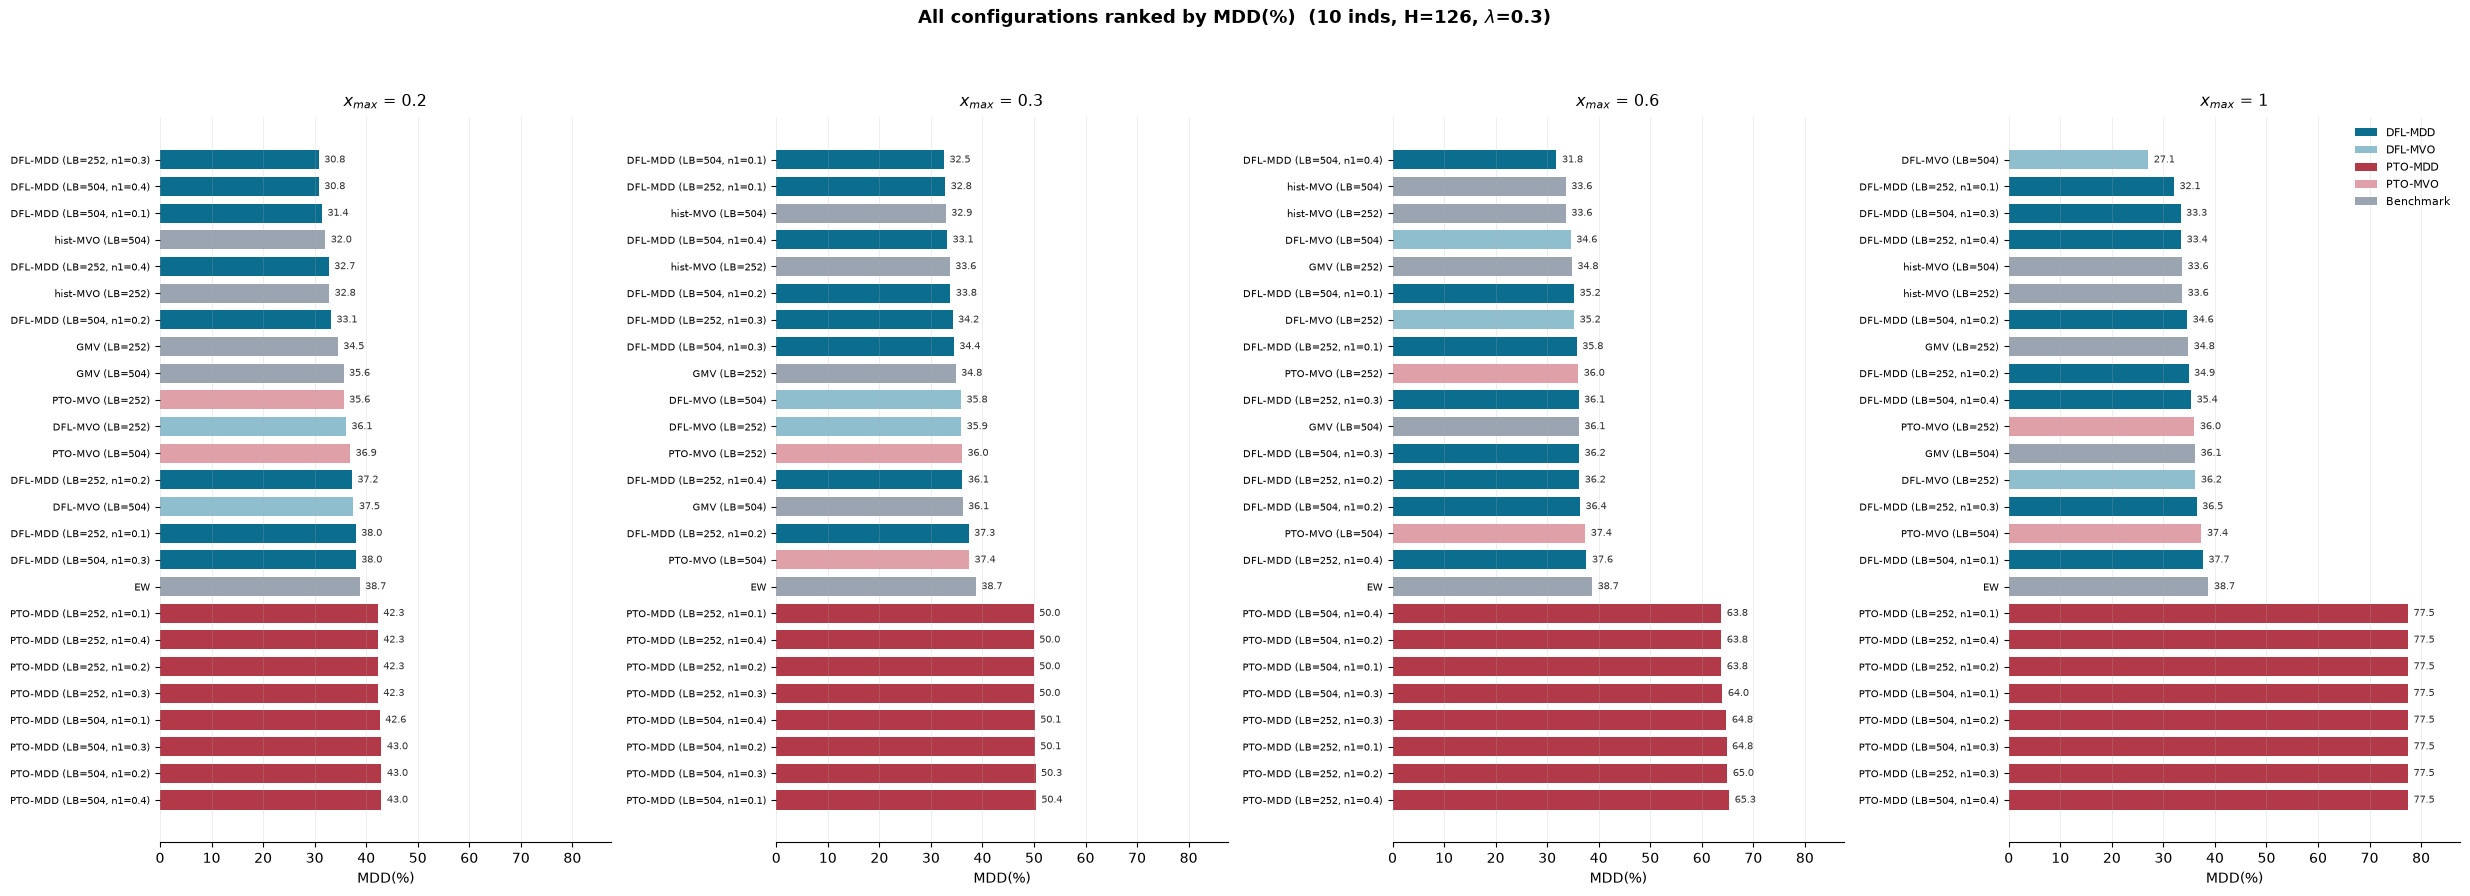

  ✓ ./plots/xmax/ranked_MDD_xmax_10_inds_h126_lam0.3.png


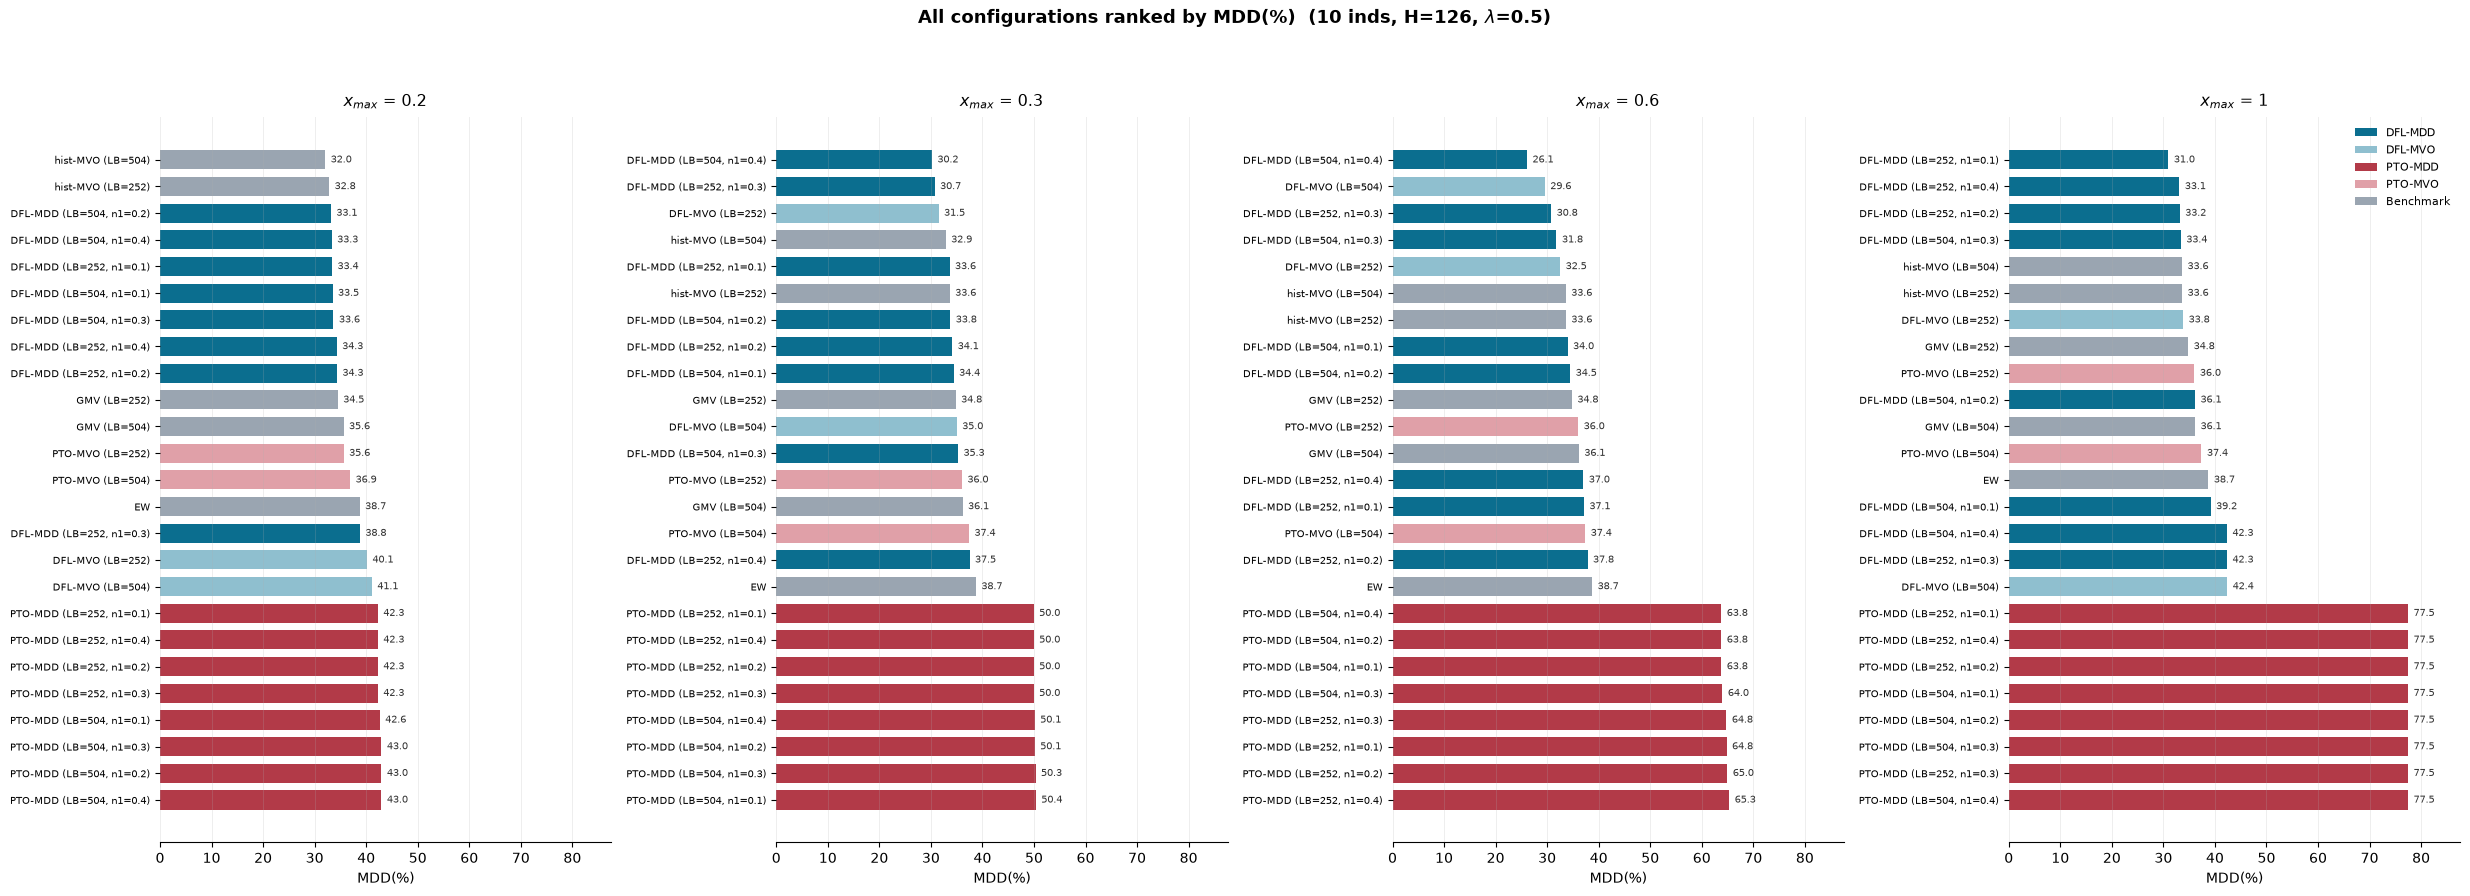

  ✓ ./plots/xmax/ranked_MDD_xmax_10_inds_h126_lam0.5.png


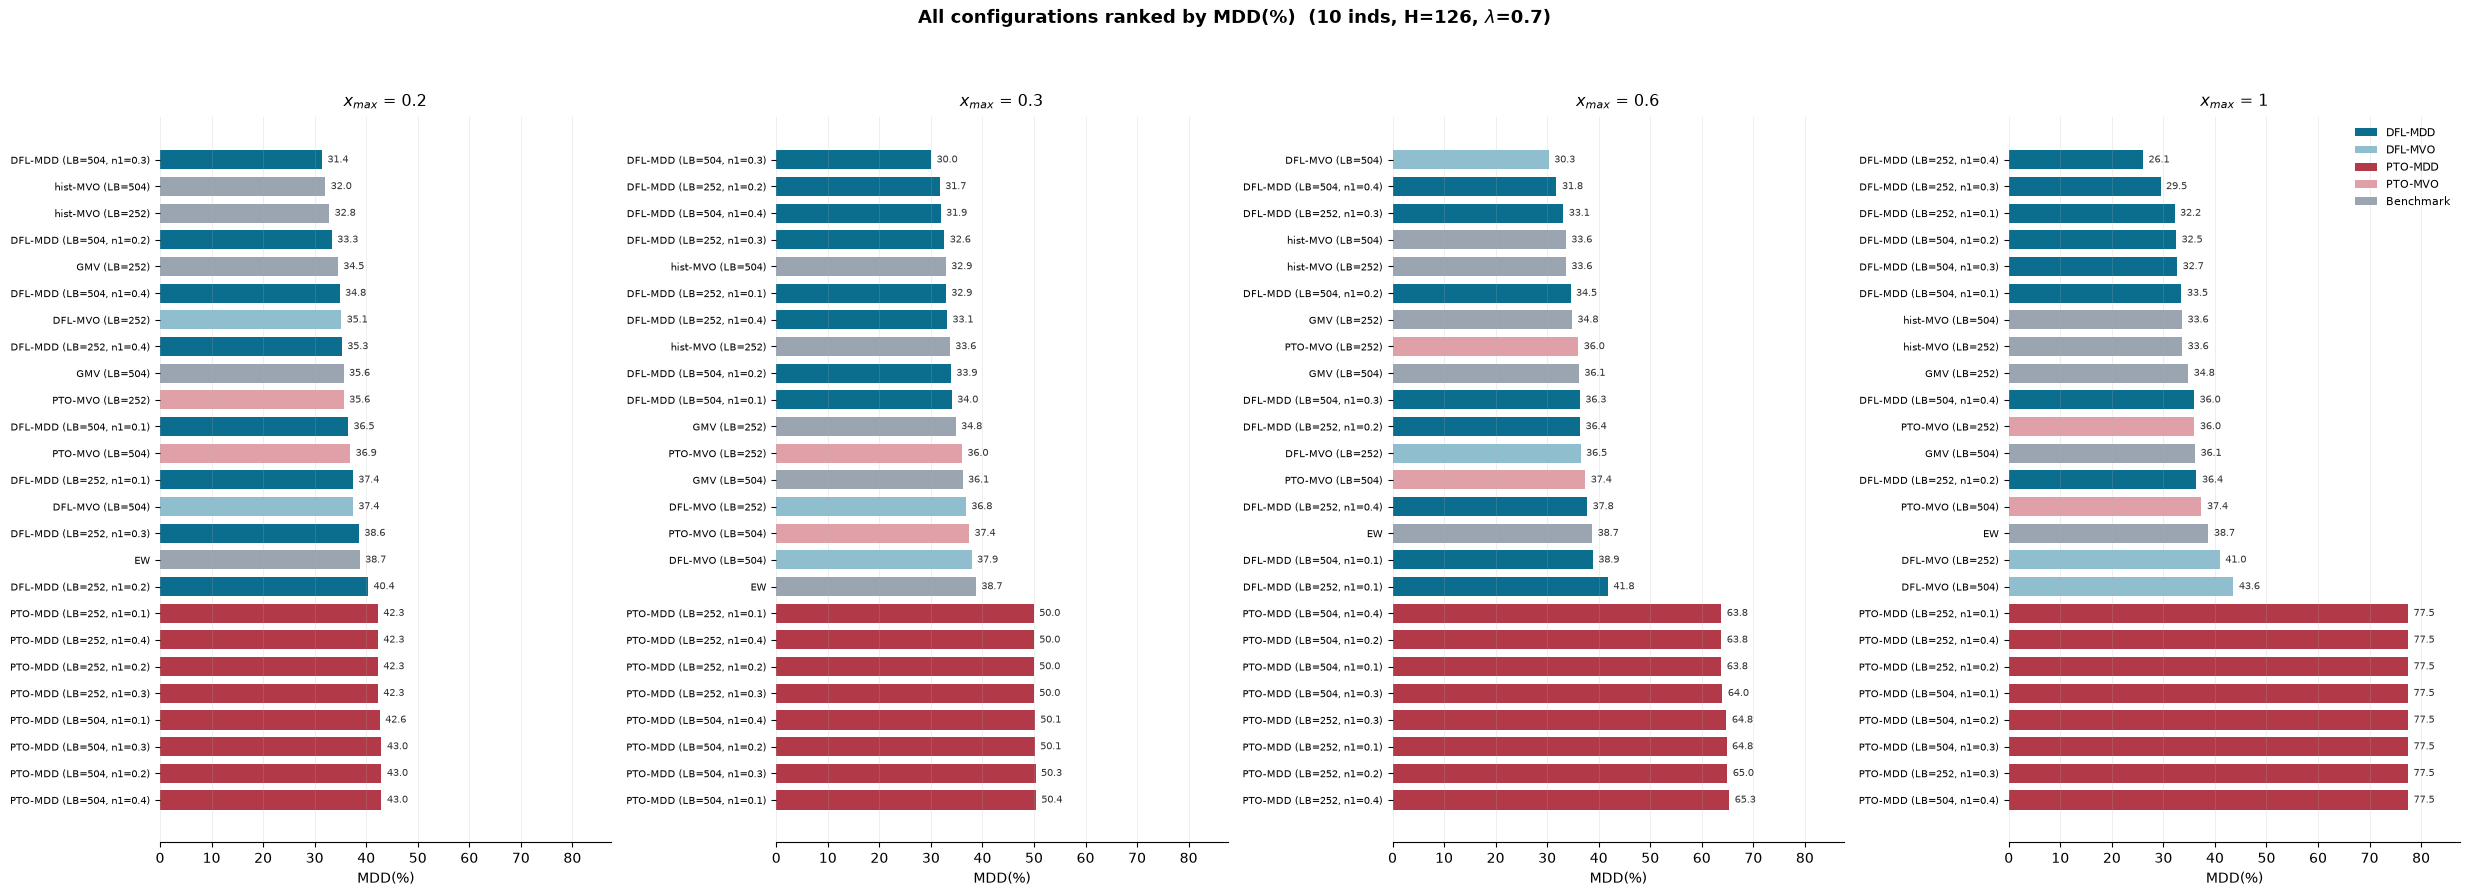

  ✓ ./plots/xmax/ranked_MDD_xmax_10_inds_h126_lam0.7.png


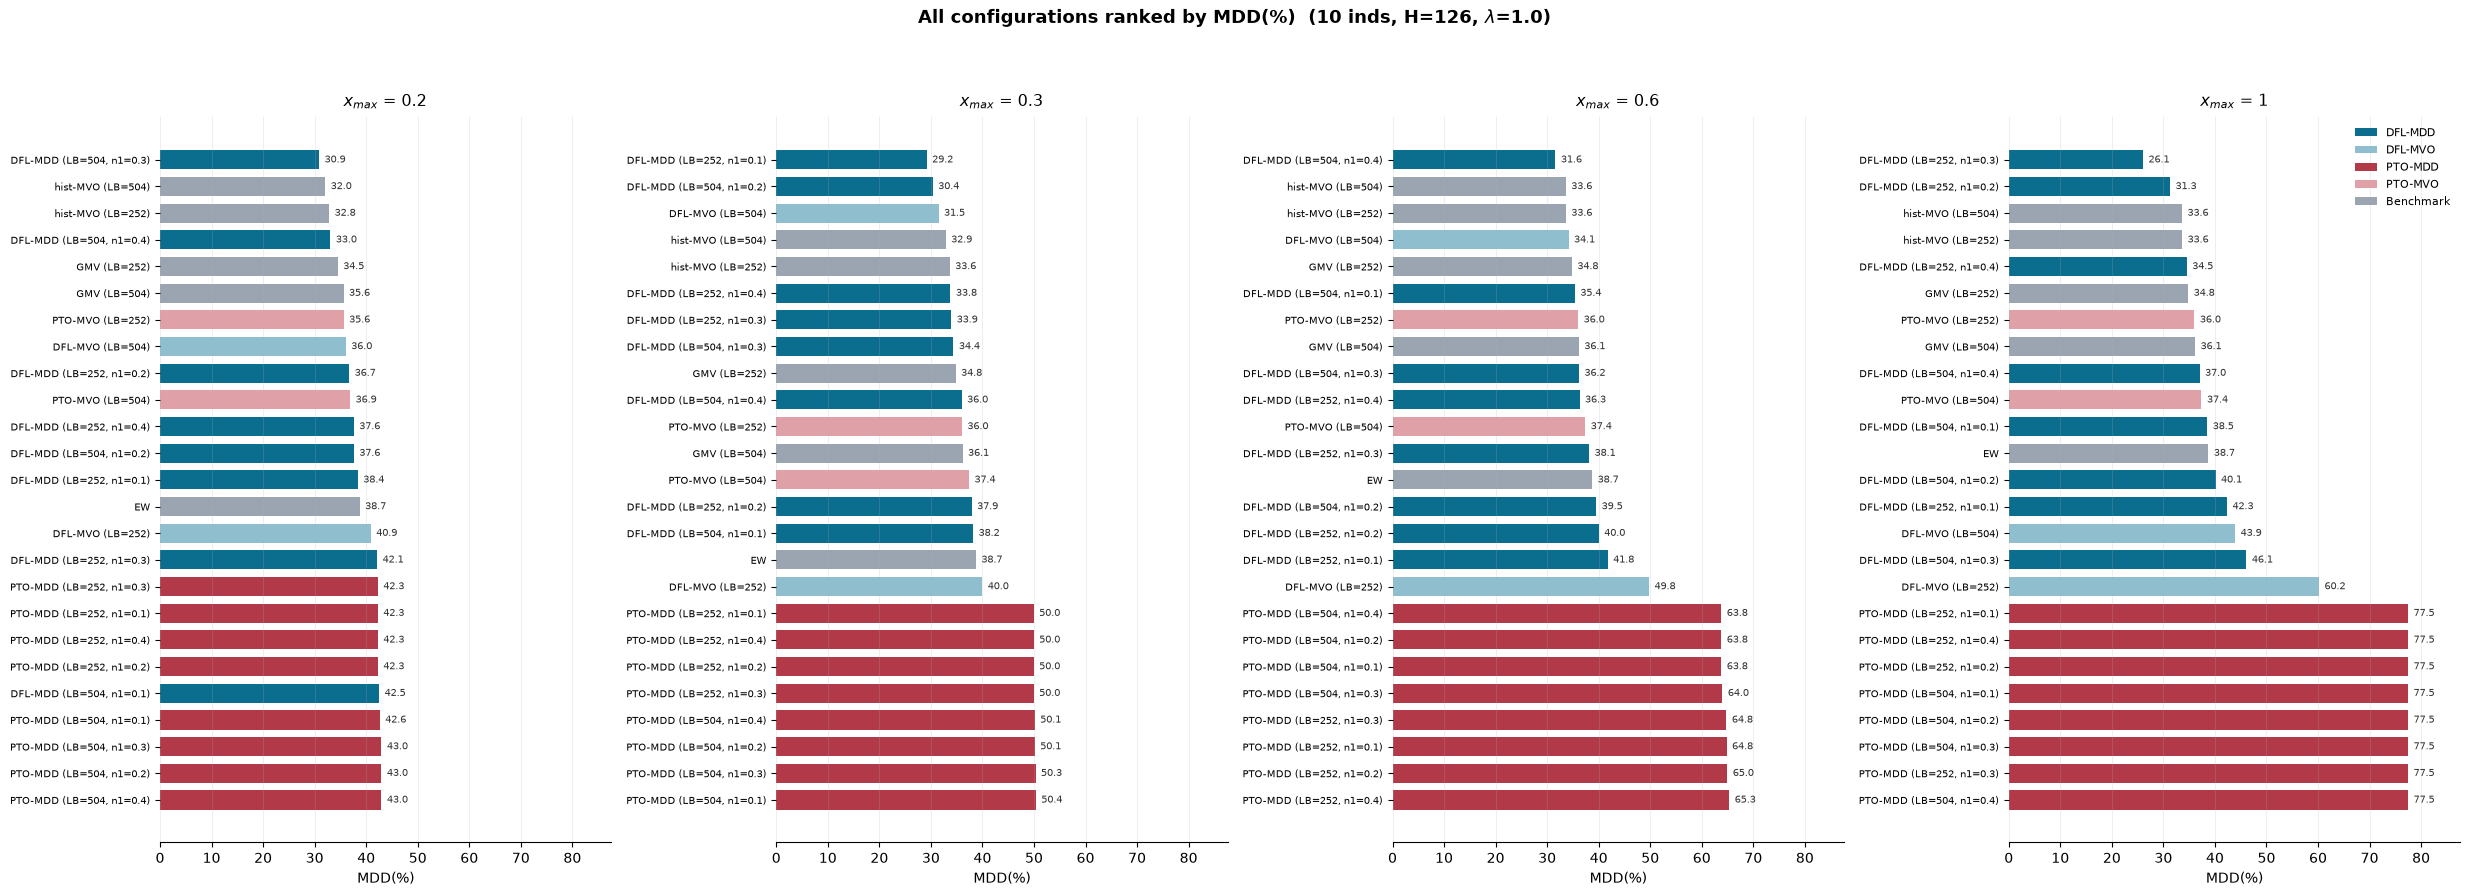

  ✓ ./plots/xmax/ranked_MDD_xmax_10_inds_h126_lam1.0.png


In [89]:
# ══════════════════════════════════════════════════════════
#  전체 config 를 MDD 기준으로 정렬 — x_max 3개를 나란히 비교
#  (기존 ranked_MDD 그림의 weight-cap 버전)
# ══════════════════════════════════════════════════════════
from matplotlib.patches import Patch

METRIC = "MDD(%)"          # "Calmar", "Sharpe", "Turnover" 로도 가능
PAL = {"DFL-MDD": "#0B6E8F", "DFL-MVO": "#8FBFCF",
       "PTO-MDD": "#B23A48", "PTO-MVO": "#E0A0A8",
       "Benchmark": "#9AA5B1"}
XMS = sorted(DATA)
ASC = METRIC not in ("Calmar", "Sharpe", "Ann.Ret(%)")   # MDD·Turnover 는 작을수록 좋음

xmax_axis = df_xm[METRIC].max() * 1.13

for LAM in LAM_LIST:
    sub = df_xm[df_xm.lam == LAM]
    if sub.empty:
        continue
    nrow = int(sub.groupby("x_max").size().max())
    fig, axes = plt.subplots(1, len(XMS),
                             figsize=(6.2 * len(XMS), 0.30 * nrow + 1.6),
                             sharex=True)
    axes = np.atleast_1d(axes)

    for ax, xm in zip(axes, XMS):
        s = (sub[sub.x_max == xm]
             .groupby(["group", "label"])[METRIC].mean()
             .reset_index()
             .sort_values(METRIC, ascending=ASC))
        y = np.arange(len(s))
        ax.barh(y, s[METRIC], height=0.72, edgecolor="none",
                color=[PAL.get(g, "#999") for g in s.group])
        for i, v in enumerate(s[METRIC]):
            ax.text(v + xmax_axis * 0.012, i, f"{v:.1f}",
                    va="center", fontsize=7.5, color="#333")
        ax.set_yticks(y)
        ax.set_yticklabels(s.label, fontsize=7.5)
        ax.invert_yaxis()
        ax.set_xlim(0, xmax_axis)
        ax.set_xlabel(METRIC, fontsize=10)
        ax.set_title(f"$x_{{max}}$ = {xm:g}", fontsize=11.5, pad=8)
        ax.grid(axis="x", alpha=0.22, lw=0.7)
        for sp in ("top", "right", "left"):
            ax.spines[sp].set_visible(False)

    axes[-1].legend(handles=[Patch(facecolor=c, label=g) for g, c in PAL.items()
                             if g in set(sub.group)],
                    fontsize=8, loc="upper right", frameon=False)
    fig.suptitle(f"All configurations ranked by {METRIC}  "
                 f"({N_STOCKS} inds, H={HORIZON}, $\\lambda$={LAM})",
                 fontsize=13, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.94])

    m_tag = (METRIC.replace("(%)", "").replace("(", "")
             .replace(")", "").replace("%", ""))
    out = (f"{PLOT_DIR}/ranked_{m_tag}_xmax_{N_STOCKS}_inds"
           f"_h{HORIZON}_lam{LAM}.png")
    plt.savefig(out, bbox_inches="tight", dpi=600)
    plt.show()
    print(f"  ✓ {out}")

## 6. 거래비용 반영

In [90]:
TCS = [0, 5, 10, 20, 40]
rows = []
for xm, D in sorted(DATA.items()):
    for lam in LAM_LIST:
        if (DELTA, lam) not in D["cf"]: continue
        groups = [("DFL-MDD",   D["cf"][(DELTA, lam)]),
                  ("DFL-MVO",   D["mvo"].get((DELTA, lam), [])),
                  ("PTO-MDD",   D.get("pmdd", [])),
                  ("PTO-MVO",   D.get("pmvo", [])),
                  ("Benchmark", [(v, k) for k, v in D["bench"].items()])]
        for tc in TCS:
            for g, items in groups:
                for res, lbl in items:
                    r2 = apply_tc(res, tc / 1e4, full_np, REBAL) if tc else res
                    p  = compute_performance(r2)
                    to = compute_turnover(res, full_np, REBAL)["mean"]
                    w  = np.array([r["weights"] for r in res], dtype=float)
                    rows.append({"x_max": xm, "lam": lam, "tc_bps": tc,
                                 "group": g, "label": lbl,
                                 "Ann.Ret(%)": round(p["Ann.Ret"] * 100, 2),
                                 "Sharpe": round(p["Sharpe"], 4),
                                 "CVaR(5%)(%)": round(p["CVaR(5%)"] * 100, 2),
                                 "MDD(%)": round(p["MDD"] * 100, 2),
                                 "MDD_abs(%)": round(p["MDD_abs"] * 100, 2),
                                 "Calmar": round(p["Calmar"], 4),
                                 "HHI": round(p["HHI"], 4),
                                 "MaxW": round(float(w.max()), 4),
                                 "Turnover": round(to, 4)})
df_tc = pd.DataFrame(rows)

# ── ① 통합본 ──
allout = f"{RESULT_DIR}/{N_STOCKS}_inds_h{HORIZON}_xmax_tc_all.csv"
df_tc.to_csv(allout, index=False, encoding="utf-8-sig")
print(f"✓ 통합: {os.path.basename(allout)}  ({len(df_tc)}행)\n")

# ── ② x_max × λ 별 분리 저장 ──
for xm in sorted(df_tc.x_max.unique()):
    for lam in sorted(df_tc.lam.unique()):
        s = df_tc[(df_tc.x_max == xm) & (df_tc.lam == lam)]
        if s.empty: continue
        out = (f"{RESULT_DIR}/{N_STOCKS}_inds_h{HORIZON}"
               f"_xm{xm:g}_tc_cf_lam{lam}.csv")
        s.drop(columns=["x_max", "lam"]).to_csv(out, index=False,
                                                encoding="utf-8-sig")
        print(f"  ✓ {os.path.basename(out)}  ({len(s)}행)")

print("\n── Calmar: tc × x_max (DFL-MDD 평균) ──")
display(df_tc[df_tc.group == "DFL-MDD"].pivot_table(
    index="tc_bps", columns="x_max", values="Calmar").round(4))
print("── Turnover: x_max × group ──")
display(df_tc[df_tc.tc_bps == 0].pivot_table(
    index="group", columns="x_max", values="Turnover").round(4))

✓ 통합: 10_inds_h126_xmax_tc_all.csv  (2000행)

  ✓ 10_inds_h126_xm0.2_tc_cf_lam0.3.csv  (125행)
  ✓ 10_inds_h126_xm0.2_tc_cf_lam0.5.csv  (125행)
  ✓ 10_inds_h126_xm0.2_tc_cf_lam0.7.csv  (125행)
  ✓ 10_inds_h126_xm0.2_tc_cf_lam1.0.csv  (125행)
  ✓ 10_inds_h126_xm0.3_tc_cf_lam0.3.csv  (125행)
  ✓ 10_inds_h126_xm0.3_tc_cf_lam0.5.csv  (125행)
  ✓ 10_inds_h126_xm0.3_tc_cf_lam0.7.csv  (125행)
  ✓ 10_inds_h126_xm0.3_tc_cf_lam1.0.csv  (125행)
  ✓ 10_inds_h126_xm0.6_tc_cf_lam0.3.csv  (125행)
  ✓ 10_inds_h126_xm0.6_tc_cf_lam0.5.csv  (125행)
  ✓ 10_inds_h126_xm0.6_tc_cf_lam0.7.csv  (125행)
  ✓ 10_inds_h126_xm0.6_tc_cf_lam1.0.csv  (125행)
  ✓ 10_inds_h126_xm1_tc_cf_lam0.3.csv  (125행)
  ✓ 10_inds_h126_xm1_tc_cf_lam0.5.csv  (125행)
  ✓ 10_inds_h126_xm1_tc_cf_lam0.7.csv  (125행)
  ✓ 10_inds_h126_xm1_tc_cf_lam1.0.csv  (125행)

── Calmar: tc × x_max (DFL-MDD 평균) ──


x_max,0.2,0.3,0.6,1.0
tc_bps,,,,
0,0.2931,0.2869,0.2561,0.2333
5,0.2887,0.2798,0.2463,0.2220
10,0.2843,0.2728,0.2365,0.2107
20,0.2755,0.2586,0.2170,0.1884
40,0.2580,0.2306,0.1786,0.1436


── Turnover: x_max × group ──


x_max,0.2,0.3,0.6,1.0
group,,,,
Benchmark,0.0945,0.1104,0.1170,0.1170
DFL-MDD,0.2312,0.3593,0.5162,0.6001
DFL-MVO,0.2061,0.3125,0.3794,0.4892
PTO-MDD,0.0548,0.0663,0.0933,0.0842
PTO-MVO,0.0577,0.0662,0.0674,0.0674


## 7. 누적수익 비교

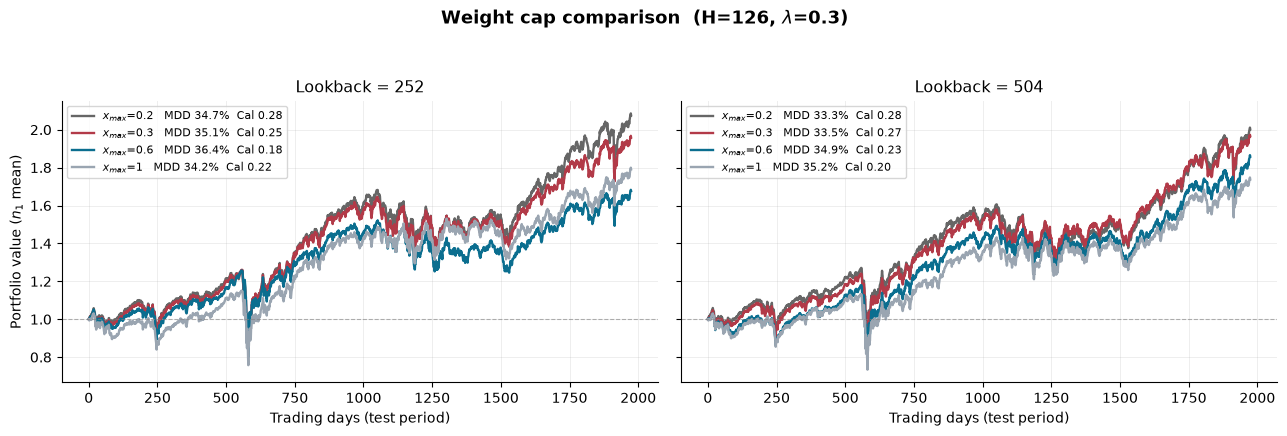

  ✓ ./plots/xmax/cumret_xmax_10_inds_h126_lam0.3.png


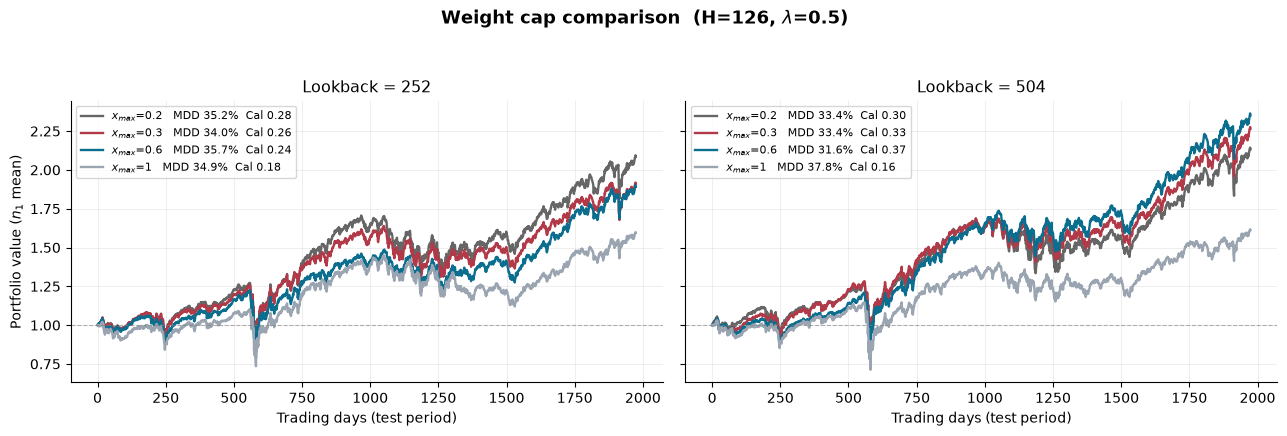

  ✓ ./plots/xmax/cumret_xmax_10_inds_h126_lam0.5.png


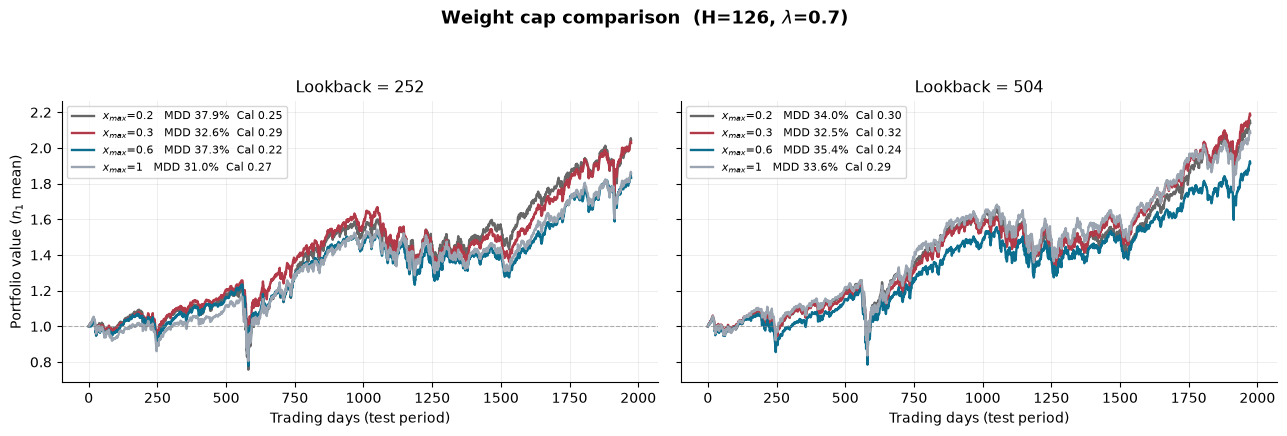

  ✓ ./plots/xmax/cumret_xmax_10_inds_h126_lam0.7.png


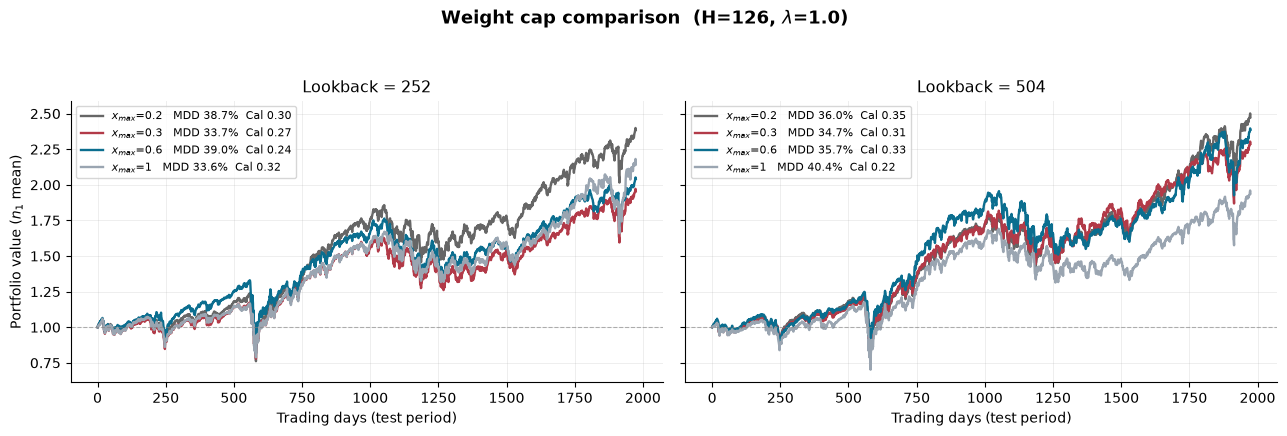

  ✓ ./plots/xmax/cumret_xmax_10_inds_h126_lam1.0.png


In [92]:
XM_COL = {1.0: "#9AA5B1", 0.6: "#0B6E8F", 0.3: "#B23A48"}

for lam in LAM_LIST:
    avail = [xm for xm in sorted(DATA) if (DELTA, lam) in DATA[xm]["cf"]]
    if not avail: continue
    fig, axes = plt.subplots(1, len(LOOKBACK_LIST), figsize=(13, 4.4), sharey=True)
    axes = np.atleast_1d(axes)
    for ax, lb in zip(axes, LOOKBACK_LIST):
        for xm in avail:
            sel = [res for res, l in DATA[xm]["cf"][(DELTA, lam)] if parse_lb(l) == lb]
            if not sel: continue
            eqs = [build_equity_curve(r) for r in sel]
            L   = min(len(e) for e in eqs)
            eq  = np.mean([e[:L] for e in eqs], axis=0)      # n1 4개 평균
            mdd = np.mean([compute_performance(r)["MDD"] for r in sel])
            cal = np.mean([compute_performance(r)["Calmar"] for r in sel])
            ax.plot(eq, color=XM_COL.get(xm, "#666"), lw=1.7,
                    label=f"$x_{{max}}$={xm:g}   MDD {mdd:.1%}  Cal {cal:.2f}")
        ax.axhline(1.0, color="gray", ls="--", lw=0.8, alpha=0.6)
        ax.set_title(f"Lookback = {lb}", fontsize=11.5)
        ax.set_xlabel("Trading days (test period)")
        ax.legend(fontsize=8, loc="upper left")
        ax.grid(alpha=0.22, lw=0.7)
        for sp in ("top", "right"): ax.spines[sp].set_visible(False)
    axes[0].set_ylabel("Portfolio value ($n_1$ mean)")
    fig.suptitle(f"Weight cap comparison  (H={HORIZON}, $\\lambda$={lam})",
                 fontsize=13, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    out = f"{PLOT_DIR}/cumret_xmax_{N_STOCKS}_inds_h{HORIZON}_lam{lam}.png"
    plt.savefig(out, bbox_inches="tight", dpi=300)
    plt.show()
    print(f"  ✓ {out}")

## 8. 통계검정

`x_max` 별로 기존과 같은 단측 대응 t-검정을 돌린다.
DFL-MDD·DFL-MVO·벤치마크가 모두 같은 상한을 쓰므로 공정 비교가 된다.

In [94]:
from scipy import stats

ALPHAS = [0.10, 0.05, 0.01]

def sig(p1, a):
    if not np.isfinite(p1): return "n/a"
    return "✓" if p1 < a else ("✗" if p1 > 1 - a else "–")

def ttest_for(xm):
    """x_max 하나에 대해 DFL-MDD vs 나머지 전 모델의 per-window MDD 검정."""
    D = DATA[xm]

    def dates_of(st):
        return {r["date_idx"] for res, _ in st for r in res}

    # ── 공통 날짜: 비교에 들어가는 모든 모델의 교집합 ──
    sets = {"DFL-MDD": dates_of(D["cf"][(DELTA, LAM_LIST[0])]),
            "DFL-MVO": dates_of(D["mvo"][(DELTA, LAM_LIST[0])])}
    if D.get("pmdd"): sets["PTO-MDD"] = dates_of(D["pmdd"])
    if D.get("pmvo"): sets["PTO-MVO"] = dates_of(D["pmvo"])
    for l, r in D["bench"].items():
        sets[l] = {x["date_idx"] for x in r}
    COMMON = sorted(set.intersection(*sets.values()))

    def per_date(st):
        rec = {}
        for res, _ in st:
            for r in res:
                rec.setdefault(r["date_idx"], []).append(r["M_real"] * 100)
        return pd.Series({k: np.mean(v) for k, v in rec.items()}).loc[COMMON]

    def by_lb(st, lb):
        return [(r, l) for r, l in st if parse_lb(l) == lb]

    out = []
    for lb in LOOKBACK_LIST:
        for lam in LAM_LIST:
            base = per_date(by_lb(D["cf"][(DELTA, lam)], lb))

            comps = {"DFL-MVO":  by_lb(D["mvo"][(DELTA, lam)], lb),
                     "PTO-MDD":  by_lb(D.get("pmdd", []), lb),   # λ 무관
                     "PTO-MVO":  by_lb(D.get("pmvo", []), lb),   # λ 무관
                     "GMV":      [(D["bench"][f"GMV (LB={lb})"], "")],
                     "hist-MVO": [(D["bench"][f"hist-MVO (LB={lb})"], "")],
                     "EW":       [(D["bench"]["EW"], "")]}

            for nm, st in comps.items():
                if not st:                      # 해당 모델 미로드 시 건너뜀
                    continue
                x, y = base.values, per_date(st).values
                diff = x - y
                t, p2 = stats.ttest_rel(x, y)
                p1 = p2 / 2 if t < 0 else 1 - p2 / 2
                try:
                    _, w2 = stats.wilcoxon(x, y)
                    w1 = w2 / 2 if np.median(diff) < 0 else 1 - w2 / 2
                except ValueError:
                    w1 = np.nan
                out.append({"x_max": xm, "LB": lb, "lam": lam, "비교대상": nm,
                            "n": len(COMMON),
                            "DFL-MDD": round(x.mean(), 2),
                            "비교모델": round(y.mean(), 2),
                            "차이": round(diff.mean(), 2),
                            "Cohen d": round(abs(diff.mean() / diff.std(ddof=1)), 3),
                            "t": round(t, 2), "p (one-sided)": round(p1, 4),
                            **{f"유의({a:.2f})": sig(p1, a) for a in ALPHAS},
                            "Wilcoxon p": round(w1, 4)})
    return pd.DataFrame(out)

res_all = pd.concat([ttest_for(xm) for xm in sorted(DATA)], ignore_index=True)
out = f"{RESULT_DIR}/{N_STOCKS}_inds_h{HORIZON}_xmax_ttest.csv"
res_all.to_csv(out, index=False, encoding="utf-8-sig")
print(f"✓ 저장: {out}  ({len(res_all)}행)")
print(f"  x_max {sorted(res_all.x_max.unique())}, "
      f"비교대상 {sorted(res_all['비교대상'].unique())}\n")

for xm in sorted(DATA):
    print(f"[x_max = {xm:g}]  α = 0.05")
    display(res_all[res_all.x_max == xm].pivot_table(
        index="비교대상", columns=["LB", "lam"],
        values="유의(0.05)", aggfunc="first"))

✓ 저장: ./results/10_inds_h126_xmax_ttest.csv  (192행)
  x_max [np.float64(0.2), np.float64(0.3), np.float64(0.6), np.float64(1.0)], 비교대상 ['DFL-MVO', 'EW', 'GMV', 'PTO-MDD', 'PTO-MVO', 'hist-MVO']

[x_max = 0.2]  α = 0.05


LB       252             504            
lam      0.3 0.5 0.7 1.0 0.3 0.5 0.7 1.0
비교대상                                    
DFL-MVO    ✓   ✓   –   ✓   ✓   ✓   ✓   –
EW         ✓   ✓   ✓   ✓   ✓   ✓   ✓   ✓
GMV        ✗   ✗   ✗   ✗   –   –   –   ✗
PTO-MDD    ✓   ✓   –   –   ✓   ✓   ✓   –
PTO-MVO    –   –   ✗   ✗   –   –   –   ✗
hist-MVO   –   –   –   ✗   ✓   ✓   –   –

[x_max = 0.3]  α = 0.05


LB       252             504            
lam      0.3 0.5 0.7 1.0 0.3 0.5 0.7 1.0
비교대상                                    
DFL-MVO    ✗   ✓   ✓   ✓   ✓   –   –   –
EW         ✓   ✓   ✓   –   ✓   ✓   ✓   –
GMV        ✗   ✗   –   ✗   –   –   –   ✗
PTO-MDD    ✓   ✓   ✓   –   ✓   ✓   ✓   ✓
PTO-MVO    ✗   ✗   –   ✗   ✓   –   –   ✗
hist-MVO   –   –   –   ✗   ✓   ✓   –   ✗

[x_max = 0.6]  α = 0.05


LB       252             504            
lam      0.3 0.5 0.7 1.0 0.3 0.5 0.7 1.0
비교대상                                    
DFL-MVO    –   ✓   ✓   ✓   –   –   –   –
EW         ✓   ✓   ✓   –   ✓   ✓   ✓   –
GMV        ✗   ✗   ✗   ✗   –   –   ✗   ✗
PTO-MDD    ✓   ✓   ✓   ✓   ✓   ✓   ✓   ✓
PTO-MVO    ✗   ✗   ✗   ✗   –   –   ✗   ✗
hist-MVO   –   –   –   ✗   ✓   ✓   –   ✗

[x_max = 1]  α = 0.05


LB       252             504            
lam      0.3 0.5 0.7 1.0 0.3 0.5 0.7 1.0
비교대상                                    
DFL-MVO    ✓   ✓   ✓   ✓   ✓   ✓   –   ✓
EW         ✓   ✓   ✓   –   ✓   ✓   ✓   ✗
GMV        –   ✗   ✗   ✗   –   –   ✗   ✗
PTO-MDD    ✓   ✓   ✓   ✓   ✓   ✓   ✓   ✓
PTO-MVO    –   ✗   ✗   ✗   –   –   ✗   ✗
hist-MVO   –   –   –   ✗   –   –   –   ✗